In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
# Config
pd.set_option("display.max_columns", None)
sns.set_theme(style="darkgrid")

# Load data
data = pd.read_csv("Linhac24-25_Sportlogiq.csv")

# Overview
print(data.shape)
print(data.dtypes)
print(data.describe())
print(data.isnull().sum())

data.head(10)

(541802, 22)
gameid                             int64
opposingteamgoalieoniceid        float64
opposingteamid                     int64
playerid                           int64
teamgoalieoniceid                float64
teamid                             int64
teaminpossession                 float64
currentpossession                float64
xg_allattempts                   float64
compiledgametime                 float64
eventname                         object
ishomegame                         int64
manpowersituation                 object
opposingteamskatersonicecount      int64
outcome                           object
period                             int64
playerprimaryposition             object
scoredifferential                  int64
teamskatersonicecount              int64
type                              object
xadjcoord                        float64
yadjcoord                        float64
dtype: object
              gameid  opposingteamgoalieoniceid  opposingteamid  \
coun

,gameid,opposingteamgoalieoniceid,opposingteamid,playerid,teamgoalieoniceid,teamid,teaminpossession,currentpossession,xg_allattempts,compiledgametime,eventname,ishomegame,manpowersituation,opposingteamskatersonicecount,outcome,period,playerprimaryposition,scoredifferential,teamskatersonicecount,type,xadjcoord,yadjcoord
0,72393,553243.0,885,489917,172367.0,814,NaN,NaN,NaN,0.000000,faceoff,1,evenStrength,5,failed,1,F,0,5,none,0.304306,0.251442
1,72393,172367.0,814,435025,553243.0,885,NaN,NaN,NaN,0.000000,faceoff,0,evenStrength,5,successful,1,F,0,5,recovered,-0.304306,-0.251442
2,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,1.333333,lpr,0,evenStrength,5,successful,1,F,0,5,faceoffcontested,0.205826,0.245975
3,72393,553243.0,885,489917,172367.0,814,885.0,0.0,NaN,1.333333,lpr,1,evenStrength,5,failed,1,F,0,5,contested,-0.205826,-0.245975
4,72393,172367.0,814,435025,553243.0,885,885.0,0.0,NaN,2.166667,pass,0,evenStrength,5,successful,1,F,0,5,south,3.223473,3.766563
5,72393,172367.0,814,706220,553243.0,885,885.0,0.0,NaN,2.966667,reception,0,evenStrength,5,successful,1,D,0,5,regular,-19.911827,11.310680
6,72393,172367.0,814,706220,553243.0,885,885.0,0.0,NaN,4.466667,pass,0,evenStrength,5,failed,1,D,0,5,north,-7.338295,26.398914
7,72393,553243.0,885,213380,172367.0,814,885.0,0.0,NaN,4.700000,block,1,evenStrength,5,successful,1,F,0,5,pass,1.813835,-24.897058
8,72393,553243.0,885,213380,172367.0,814,814.0,1.0,NaN,6.033333,lpr,1,evenStrength,5,successful,1,F,0,5,none,-17.800873,-40.991177
9,72393,553243.0,885,213380,172367.0,814,814.0,1.0,NaN,6.533333,puckprotection,1,evenStrength,5,successful,1,F,0,5,body,-16.794991,-40.488235


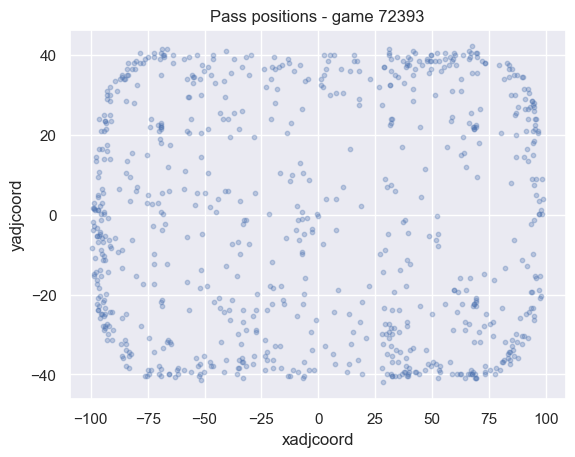

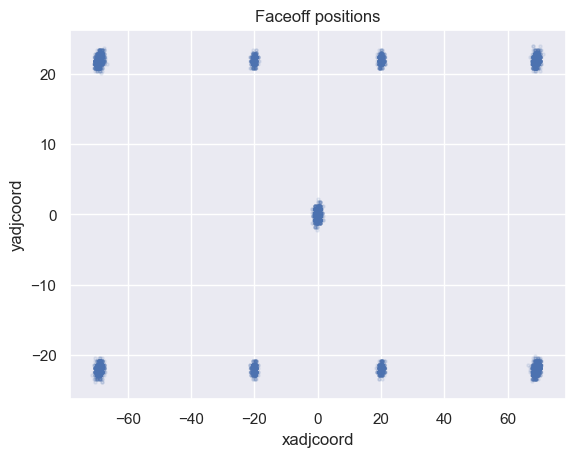

In [5]:
# Plot passes
passes = data[(data['eventname'] == 'pass') & (data['gameid'] == 72393)]
plt.scatter(passes['xadjcoord'], passes['yadjcoord'], alpha=0.3, s=10)
plt.title('Pass positions - game 72393')
plt.xlabel('xadjcoord')
plt.ylabel('yadjcoord')
plt.show()

# Plot faceoffs
faceoffs = data[data['eventname'] == 'faceoff']
plt.scatter(faceoffs['xadjcoord'], faceoffs['yadjcoord'], alpha=0.1, s=5)
plt.title('Faceoff positions')
plt.xlabel('xadjcoord')
plt.ylabel('yadjcoord')
plt.show()

In [6]:
# Alla som har controlledentry till andra zonen och alla typer hur entryn har gjorts
data[data['eventname'] == 'controlledentry']['type'].value_counts()

# Sannolikheten att ett skott resulterar i ett mål
data['xg_allattempts']

# Alla händelser som har mer än 80 % sannolikhet att bli mål 
data[data['xg_allattempts'] > 0.8][['eventname', 'xg_allattempts', 'xadjcoord', 'yadjcoord']]

,eventname,xg_allattempts,xadjcoord,yadjcoord
53328,shot,0.810006,-58.539108,38.976471
313148,shot,0.949455,-90.331482,-30.929413
326988,shot,0.882324,82.177345,-3.267647
399178,shot,0.805608,-40.032639,-40.485291
437140,shot,0.805782,-82.284424,37.973530
496175,shot,0.896192,84.692047,1.258823
538756,shot,0.809618,85.805008,-1.761765


In [7]:
data[data['eventname'] == 'controlledentry']['type'].value_counts()

type
carry                                    3755
carrywithplay                            2396
carrywithplaywithshotonnetandslotshot    1497
pass                                     1448
carrywithplaywithshotonnet               1327
carrywithplaywithslotshot                 410
passwithplay                              357
carrywithshotonnetandslotshot             354
passwithplaywithshotonnetandslotshot      316
carrywithshotonnet                        273
passwithplaywithshotonnet                 255
carrywithslotshot                         121
passwithplaywithslotshot                   73
passwithshotonnet                          60
passwithshotonnetandslotshot               60
passwithslotshot                           24
Name: count, dtype: int64

## Number of passes from start of powerplay to goal

In [20]:
num_passes = []
total_pp_seqs = 0

for game, game_df in data.groupby('gameid'):
    game_df = game_df.sort_values('compiledgametime').reset_index(drop=True)
    
    # Filter out only the powerplay teams happenings
    pp_only = game_df[game_df['manpowersituation'] == 'powerPlay'].copy().reset_index(drop=True)
    
    if len(pp_only) == 0:
        continue
    
    # New powerplay if 10 seconds gap, after a goal, or after a faceoff
    pp_only['time_gap'] = pp_only['compiledgametime'].diff()
    pp_only['prev_was_goal'] = pp_only['eventname'].shift(1) == 'goal'
    pp_only['prev_was_faceoff'] = pp_only['eventname'].shift(1) == 'faceoff'
    pp_only['pp_start'] = (pp_only['time_gap'] > 10) | (pp_only.index == 0) | pp_only['prev_was_goal'] | pp_only['prev_was_faceoff']
    pp_only['pp_seq_id'] = pp_only['pp_start'].cumsum() 
    
    for seq_id, seq_df in pp_only.groupby('pp_seq_id'):
        seq_df = seq_df.reset_index(drop=True)
        total_pp_seqs += 1
        goal_indices = seq_df[seq_df['eventname'] == 'goal'].index
        
        for goal_index in goal_indices:
            if goal_index == 0:
                pass_count = 0
            else:
                pass_count = (seq_df.loc[:goal_index - 1, 'eventname'] == 'pass').sum()
            num_passes.append({
                'gameid': game,
                'pp_seq_id': seq_id,
                'passes_before_goal': pass_count
            })

goal_pass_df = pd.DataFrame(num_passes)

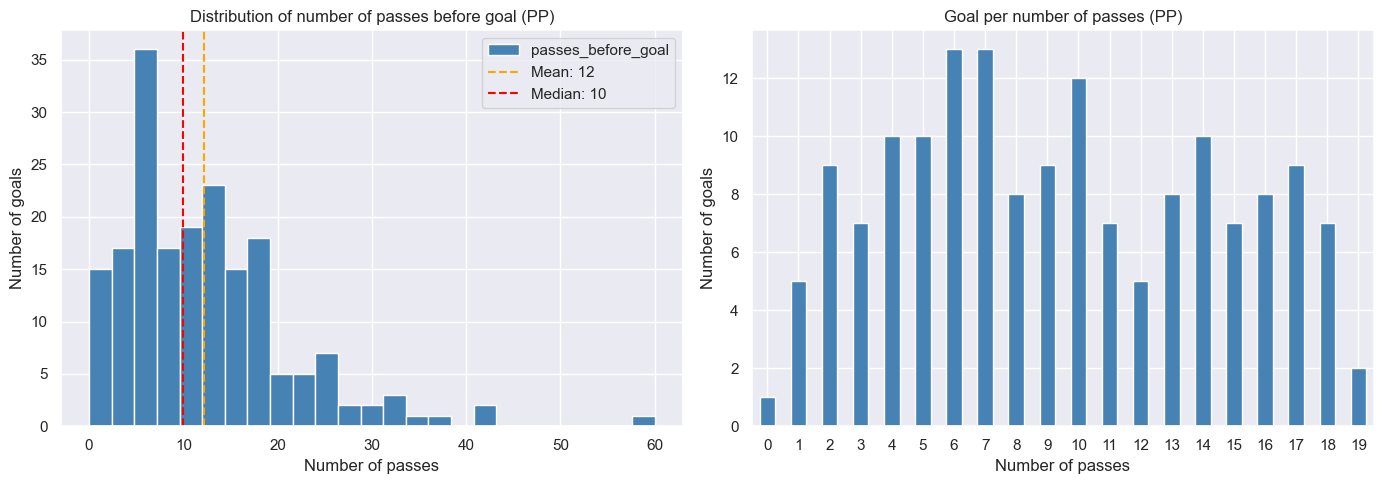

Total number of powerplays: 2461
count    189.000000
mean      12.243386
std        8.888435
min        0.000000
25%        6.000000
50%       10.000000
75%       16.000000
max       60.000000
Name: passes_before_goal, dtype: float64


In [ ]:
# Plot number of passes before a goal from the beginning of a powerplay
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

goal_pass_df['passes_before_goal'].plot(kind='hist', bins=25, ax=axes[0], color='steelblue', edgecolor='white')
axes[0].axvline(goal_pass_df['passes_before_goal'].mean(), color='orange', linestyle='--', label=f"Mean: {goal_pass_df['passes_before_goal'].mean():.0f}")
axes[0].axvline(goal_pass_df['passes_before_goal'].median(), color='red', linestyle='--', label=f"Median: {goal_pass_df['passes_before_goal'].median():.0f}")
axes[0].set_title('Distribution of number of passes before goal (PP)')
axes[0].set_xlabel('Number of passes')
axes[0].set_ylabel('Number of goals')
axes[0].legend()

goal_pass_df['passes_before_goal'].value_counts().sort_index().head(20).plot(kind='bar', ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Goal per number of passes (PP)')
axes[1].set_xlabel('Number of passes')
axes[1].set_ylabel('Number of goals')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

print(f"Total number of powerplays: {total_pp_seqs}")

print(goal_pass_df['passes_before_goal'].describe())

In [ ]:
# Same as above but for one specific team in one specific game
team_id = 885
game_id = 7239

game_df = data[(data['teamid'] == team_id) & (data['gameid'] == game_id)].sort_values('compiledgametime').reset_index(drop=True)
pp_only = game_df[game_df['manpowersituation'] == 'powerPlay'].copy().reset_index(drop=True)

pp_only['time_gap'] = pp_only['compiledgametime'].diff()
pp_only['prev_was_goal'] = pp_only['eventname'].shift(1) == 'goal'
pp_only['prev_was_faceoff'] = pp_only['eventname'].shift(1) == 'faceoff'
pp_only['pp_start'] = (pp_only['time_gap'] > 10) | (pp_only.index == 0) | pp_only['prev_was_goal'] | pp_only['prev_was_faceoff']
pp_only['pp_seq_id'] = pp_only['pp_start'].cumsum()

num_passes_single = []
total_pp_seqs_single = 0

for seq_id, seq_df in pp_only.groupby('pp_seq_id'):
    seq_df = seq_df.reset_index(drop=True)
    total_pp_seqs_single += 1
    goal_indices = seq_df[seq_df['eventname'] == 'goal'].index
    
    for goal_index in goal_indices:
        if goal_index == 0:
            pass_count = 0
        else:
            pass_count = (seq_df.loc[:goal_index - 1, 'eventname'] == 'pass').sum()
        num_passes_single.append({
            'pp_seq_id': seq_id,
            'passes_before_goal': pass_count
        })

goal_pass_single = pd.DataFrame(num_passes_single)

print(f"Lag: {team_id}, Match: {game_id}")
print(f"Totalt antal pp-sekvenser: {total_pp_seqs_single}")
print(f"Pp-sekvenser med mål: {len(goal_pass_single)}")
print(goal_pass_single)

Lag: 885, Match: 7239
Totalt antal pp-sekvenser: 0
Pp-sekvenser med mål: 0
Empty DataFrame
Columns: []
Index: []


# PP-mål per period

period
1    47
2    71
3    68
4     3
Name: count, dtype: int64


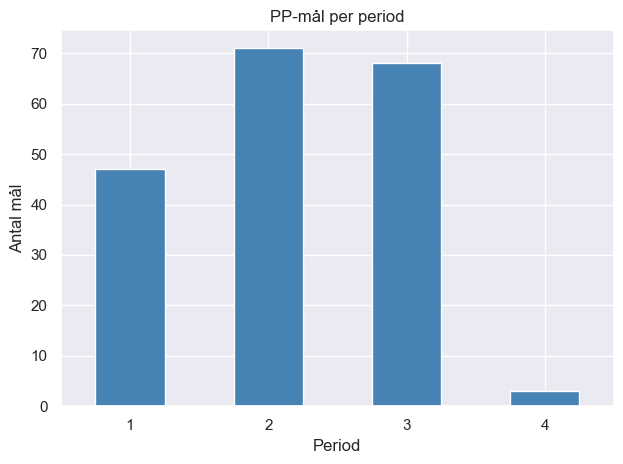

In [11]:
# PP-mål per period
pp_goals = data[(data['manpowersituation'] == 'powerPlay') & (data['eventname'] == 'goal')]

period_counts = pp_goals['period'].value_counts().sort_index()
print(period_counts)

period_counts.plot(kind='bar', color='steelblue', edgecolor='white')
plt.title('PP-mål per period')
plt.xlabel('Period')
plt.ylabel('Antal mål')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [12]:
data['manpowersituation'].value_counts()

manpowersituation
evenStrength    463668
powerPlay        59271
shortHanded      18863
Name: count, dtype: int64